<a href="https://colab.research.google.com/github/abdullaawad/Data-Warehousing-Coursework/blob/main/Copy_of_DWCoursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Install Package
!pip install yfinance
!pip install yahoofinancials


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=b70ea4364b38111bf5de24081243727654fc17438bdbec47a688d5741ffa483c
  Stored in directory: /root/.cache/pip/wheels/b0/e1/ca/e683b02e57db550881c8ebb89ba3eccb7a5c0ebfad7f03acea
Successfully built yahoofinancials


In [ ]:
import pandas as pd
import yfinance as yf
import requests
from io import StringIO
from IPython.display import display
import yfinance as yf
from yahoofinancials import YahooFinancials
from datetime import datetime
from typing import dataclass_transform
import numpy as np

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

In [ ]:
response = requests.get(url, headers=headers)
response.raise_for_status()

# Read all tables on the page
tables = pd.read_html(StringIO(response.text))

# Find the table that contains a 'Symbol' column
sp500_table = None
for table in tables:
    cols_lower = [str(c).lower() for c in table.columns]
    if "symbol" in cols_lower:
        sp500_table = table.copy()
        break

if sp500_table is None:
    raise ValueError("No table with a 'Symbol' column found on the page.")

# Standardise column name to 'Symbol'
for col in sp500_table.columns:
    if str(col).lower() == "symbol":
        symbol_col = col
        break

sp500_table.rename(columns={symbol_col: "Symbol"}, inplace=True)

# Clean tickers (BRK.B → BRK-B) for Yahoo Finance
sp500_table["Symbol"] = (
    sp500_table["Symbol"]
    .astype(str)
    .str.replace(".", "-", regex=False)
)

# FINAL LIST OF TICKERS
tickers = sp500_table["Symbol"].unique().tolist()

print("Number of tickers:", len(tickers))
display(sp500_table.head())


Number of tickers: 503


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [ ]:
# Define a start date and End Date
start = '2022-01-01'
#setting End Date
end = '2025-01-01'
data_source='yahoo'
p = yf.download(tickers, start, end)

/tmp/ipykernel_17626/1067665984.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  p = yf.download(tickers, start, end)
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')


In [ ]:
tickers

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK-B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF-B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CASY',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CIEN',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COHR',
 'COIN',
 'CL',
 'CMCSA',
 '

In [ ]:
p

Price      Adj Close            Close                                      \
Ticker             Q SNDK           A        AAPL        ABBV        ABNB   
Date                                                                        
2022-01-03       NaN  NaN  151.702164  178.103653  115.847229  172.679993   
2022-01-04       NaN  NaN  146.573669  175.843246  115.624779  170.800003   
2022-01-05       NaN  NaN  144.062759  171.165833  116.232162  162.250000   
2022-01-06       NaN  NaN  144.566864  168.308487  115.684654  159.750000   
2022-01-07       NaN  NaN  140.718079  168.474854  115.385262  166.050003   
...              ...  ...         ...         ...         ...         ...   
2024-12-24       NaN  NaN  134.457260  256.797211  172.530670  134.990005   
2024-12-26       NaN  NaN  134.190506  257.612732  171.763855  135.320007   
2024-12-27       NaN  NaN  133.904007  254.201370  170.623245  133.384995   
2024-12-30       NaN  NaN  132.797531  250.829803  168.888351  131.809998   
2024-12-31       NaN  NaN  132.963806  249.059479  170.326111  131.410004   

Price                                                      ...   Volume  \
Ticker             ABT       ACGL         ACN        ADBE  ...       WY   
Date                                                       ...            
2022-01-03  128.346024  42.362530  380.485291  564.369995  ...  3831100   
2022-01-04  125.327499  42.914051  377.766296  554.000000  ...  3089700   
2022-01-05  124.764420  42.410072  371.113495  514.429993  ...  3737600   
2022-01-06  124.745979  42.657307  353.192291  514.119995  ...  3315200   
2022-01-07  125.133636  42.856995  346.418121  510.700012  ...  3309900   
...                ...        ...         ...         ...  ...      ...   
2024-12-24  112.058296  92.669998  353.541504  447.940002  ...  1780100   
2024-12-26  112.556282  92.930000  352.368317  450.160004  ...  1736500   
2024-12-27  112.282875  92.339996  348.213379  446.480011  ...  2320500   
2024-12-30  110.144447  91.889999  344.605896  445.799988  ...  2914700   
2024-12-31  110.447136  92.349998  343.921539  444.679993  ...  3125200   

Price                                                                        \
Ticker         WYNN      XEL       XOM      XYL       XYZ      YUM      ZBH   
Date                                                                          
2022-01-03  2437800  3501100  24282400   759100   7315700  1251400  1184809   
2022-01-04  2292300  4197000  38584000   925400  14768500   935900  1400800   
2022-01-05  3439900  4166000  34033300  1090200  17546200   977900  1895715   
2022-01-06  2583200  2296000  30668500   703400  16244200   862400  1088813   
2022-01-07  1720400  2673100  23985400   765000   9426000   833700  1690230   
...             ...      ...       ...      ...       ...      ...      ...   
2024-12-24   692800   943900   7807000   379300   2197700   533000   458600   
2024-12-26  1218900  1394900   9652400   575700   2991100  1040900  1277300   
2024-12-27  1086700  2015000  11943900   552400   4140800  1146300   743400   
2024-12-30  2180100  2642900  11080800   586800   5383800  1144600  1532000   
2024-12-31  1612600  2143800  12387800   641600   4989400  1217100   683300   

Price                        
Ticker        ZBRA      ZTS  
Date                         
2022-01-03  272600  2772700  
2022-01-04  346000  4664000  
2022-01-05  403700  4749400  
2022-01-06  338300  3103400  
2022-01-07  432800  2206500  
...            ...      ...  
2024-12-24   88700  1023600  
2024-12-26  140100  2167200  
2024-12-27  287200  1800100  
2024-12-30  211300  1531400  
2024-12-31  327900  1327400  

[753 rows x 2517 columns]

In [ ]:
data = p.dropna(axis=1, how='all')
data

Price            Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2022-01-03  151.702164  178.103653  115.847229  172.679993  128.346024   
2022-01-04  146.573669  175.843246  115.624779  170.800003  125.327499   
2022-01-05  144.062759  171.165833  116.232162  162.250000  124.764420   
2022-01-06  144.566864  168.308487  115.684654  159.750000  124.745979   
2022-01-07  140.718079  168.474854  115.385262  166.050003  125.133636   
...                ...         ...         ...         ...         ...   
2024-12-24  134.457260  256.797211  172.530670  134.990005  112.058296   
2024-12-26  134.190506  257.612732  171.763855  135.320007  112.556282   
2024-12-27  133.904007  254.201370  170.623245  133.384995  112.282875   
2024-12-30  132.797531  250.829803  168.888351  131.809998  110.144447   
2024-12-31  132.963806  249.059479  170.326111  131.410004  110.447136   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2022-01-03  42.362530  380.485291  564.369995  164.526489  60.037258  ...   
2022-01-04  42.914051  377.766296  554.000000  163.040482  61.151535  ...   
2022-01-05  42.410072  371.113495  514.429993  160.523590  60.673988  ...   
2022-01-06  42.657307  353.192291  514.119995  161.034378  61.213440  ...   
2022-01-07  42.856995  346.418121  510.700012  156.808640  61.735180  ...   
...               ...         ...         ...         ...        ...  ...   
2024-12-24  92.669998  353.541504  447.940002  213.882050  48.364082  ...   
2024-12-26  92.930000  352.368317  450.160004  213.852631  48.344978  ...   
2024-12-27  92.339996  348.213379  446.480011  212.803284  48.316326  ...   
2024-12-30  91.889999  344.605896  445.799988  208.458771  47.829144  ...   
2024-12-31  92.349998  343.921539  444.679993  208.360703  48.259007  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2022-01-03  3831100  2437800  3501100  24282400   759100   7315700  1251400   
2022-01-04  3089700  2292300  4197000  38584000   925400  14768500   935900   
2022-01-05  3737600  3439900  4166000  34033300  1090200  17546200   977900   
2022-01-06  3315200  2583200  2296000  30668500   703400  16244200   862400   
2022-01-07  3309900  1720400  2673100  23985400   765000   9426000   833700   
...             ...      ...      ...       ...      ...       ...      ...   
2024-12-24  1780100   692800   943900   7807000   379300   2197700   533000   
2024-12-26  1736500  1218900  1394900   9652400   575700   2991100  1040900   
2024-12-27  2320500  1086700  2015000  11943900   552400   4140800  1146300   
2024-12-30  2914700  2180100  2642900  11080800   586800   5383800  1144600   
2024-12-31  3125200  1612600  2143800  12387800   641600   4989400  1217100   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2022-01-03  1184809  272600  2772700  
2022-01-04  1400800  346000  4664000  
2022-01-05  1895715  403700  4749400  
2022-01-06  1088813  338300  3103400  
2022-01-07  1690230  432800  2206500  
...             ...     ...      ...  
2024-12-24   458600   88700  1023600  
2024-12-26  1277300  140100  2167200  
2024-12-27   743400  287200  1800100  
2024-12-30  1532000  211300  1531400  
2024-12-31   683300  327900  1327400  

[753 rows x 2505 columns]

In [ ]:
data = data['Close']
data

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702164,178.103653,115.847229,172.679993,128.346024,42.362530,380.485291,564.369995,164.526489,60.037258,...,33.979389,85.125771,59.164787,54.760235,110.957489,164.029999,125.887207,120.797714,583.900024,224.021210
2022-01-04,146.573669,175.843246,115.624779,170.800003,125.327499,42.914051,377.766296,554.000000,163.040482,61.151535,...,34.414913,84.854218,59.539246,56.819996,112.134537,156.330002,126.560326,122.023193,587.599976,215.492264
2022-01-05,144.062759,171.165833,116.232162,162.250000,124.764420,42.410072,371.113495,514.429993,160.523590,60.673988,...,33.560608,81.711823,60.122711,57.526684,110.606262,143.490005,124.955940,121.620949,558.179993,207.298355
2022-01-06,144.566864,168.308487,115.684654,159.750000,124.745979,42.657307,353.192291,514.119995,161.034378,61.213440,...,33.828625,82.090080,59.652451,58.879761,110.454376,144.660004,126.246811,120.610619,555.159973,208.121613
2022-01-07,140.718079,168.474854,115.385262,166.050003,125.133636,42.856995,346.418121,510.700012,156.808640,61.735180,...,33.786755,82.002792,60.174969,59.362366,109.571602,141.539993,124.799225,119.880951,530.859985,202.062317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,134.457260,256.797211,172.530670,134.990005,112.058296,92.669998,353.541504,447.940002,213.882050,48.364082,...,27.116615,87.733505,65.030975,101.953659,116.360298,91.080002,131.828491,105.724747,395.440002,161.848907
2024-12-26,134.190506,257.612732,171.763855,135.320007,112.556282,92.930000,352.368317,450.160004,213.852631,48.344978,...,27.030256,88.257263,65.002380,102.039909,116.675453,91.480003,132.805008,105.675476,396.850006,162.654694
2024-12-27,133.904007,254.201370,170.623245,133.384995,112.282875,92.339996,348.213379,446.480011,212.803284,48.316326,...,26.857538,87.634689,64.964241,102.030327,115.749687,88.970001,132.053085,105.301048,389.070007,161.750641


In [ ]:
data.dropna(axis=1, how='all')

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702164,178.103653,115.847229,172.679993,128.346024,42.362530,380.485291,564.369995,164.526489,60.037258,...,33.979389,85.125771,59.164787,54.760235,110.957489,164.029999,125.887207,120.797714,583.900024,224.021210
2022-01-04,146.573669,175.843246,115.624779,170.800003,125.327499,42.914051,377.766296,554.000000,163.040482,61.151535,...,34.414913,84.854218,59.539246,56.819996,112.134537,156.330002,126.560326,122.023193,587.599976,215.492264
2022-01-05,144.062759,171.165833,116.232162,162.250000,124.764420,42.410072,371.113495,514.429993,160.523590,60.673988,...,33.560608,81.711823,60.122711,57.526684,110.606262,143.490005,124.955940,121.620949,558.179993,207.298355
2022-01-06,144.566864,168.308487,115.684654,159.750000,124.745979,42.657307,353.192291,514.119995,161.034378,61.213440,...,33.828625,82.090080,59.652451,58.879761,110.454376,144.660004,126.246811,120.610619,555.159973,208.121613
2022-01-07,140.718079,168.474854,115.385262,166.050003,125.133636,42.856995,346.418121,510.700012,156.808640,61.735180,...,33.786755,82.002792,60.174969,59.362366,109.571602,141.539993,124.799225,119.880951,530.859985,202.062317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,134.457260,256.797211,172.530670,134.990005,112.058296,92.669998,353.541504,447.940002,213.882050,48.364082,...,27.116615,87.733505,65.030975,101.953659,116.360298,91.080002,131.828491,105.724747,395.440002,161.848907
2024-12-26,134.190506,257.612732,171.763855,135.320007,112.556282,92.930000,352.368317,450.160004,213.852631,48.344978,...,27.030256,88.257263,65.002380,102.039909,116.675453,91.480003,132.805008,105.675476,396.850006,162.654694
2024-12-27,133.904007,254.201370,170.623245,133.384995,112.282875,92.339996,348.213379,446.480011,212.803284,48.316326,...,26.857538,87.634689,64.964241,102.030327,115.749687,88.970001,132.053085,105.301048,389.070007,161.750641


In [ ]:
data.head(10)

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702164,178.103653,115.847229,172.679993,128.346024,42.362530,380.485291,564.369995,164.526489,60.037258,...,33.979389,85.125771,59.164787,54.760235,110.957489,164.029999,125.887207,120.797714,583.900024,224.021210
2022-01-04,146.573669,175.843246,115.624779,170.800003,125.327499,42.914051,377.766296,554.000000,163.040482,61.151535,...,34.414913,84.854218,59.539246,56.819996,112.134537,156.330002,126.560326,122.023193,587.599976,215.492264
2022-01-05,144.062759,171.165833,116.232162,162.250000,124.764420,42.410072,371.113495,514.429993,160.523590,60.673988,...,33.560608,81.711823,60.122711,57.526684,110.606262,143.490005,124.955940,121.620949,558.179993,207.298355
2022-01-06,144.566864,168.308487,115.684654,159.750000,124.745979,42.657307,353.192291,514.119995,161.034378,61.213440,...,33.828625,82.090080,59.652451,58.879761,110.454376,144.660004,126.246811,120.610619,555.159973,208.121613
2022-01-07,140.718079,168.474854,115.385262,166.050003,125.133636,42.856995,346.418121,510.700012,156.808640,61.735180,...,33.786755,82.002792,60.174969,59.362366,109.571602,141.539993,124.799225,119.880951,530.859985,202.062317
2022-01-10,140.727768,168.494400,116.677017,160.710007,124.856758,43.760349,348.520508,525.830017,158.257462,61.841309,...,33.627621,79.694489,60.836792,59.009014,108.460960,144.479996,123.056534,118.711624,535.409973,203.507751
2022-01-11,142.162598,171.322388,117.173187,168.610001,125.262878,44.093163,350.491943,529.890015,161.257324,62.327705,...,34.113388,82.730179,59.739532,61.491081,110.293022,148.429993,120.474800,120.096123,538.570007,203.699173
2022-01-12,144.944962,171.762756,117.446930,169.539993,123.435173,44.188255,353.349213,532.369995,161.368729,62.274624,...,34.381413,83.215134,59.730827,61.310104,110.283524,145.470001,119.082489,117.476807,538.440002,203.708740
2022-01-13,140.737442,168.494400,115.407089,166.000000,120.100334,44.445000,338.529114,516.900024,157.681625,62.699104,...,34.892307,81.692436,60.105293,60.870567,108.612846,136.949997,118.768997,119.806107,525.799988,198.147202


# ***Daily Returns:***

In [ ]:
#daily returns
daily_returns = data.pct_change()
daily_returns = daily_returns.iloc[1:]

In [ ]:
dr_mean = daily_returns.mean()
dr_mean.name = 'Average Daily returns'
dr_mean

,Average Daily returns
Ticker,
A,-0.000002
AAPL,0.000591
ABBV,0.000610
ABNB,0.000074
ABT,-0.000106
...,...
XYZ,-0.000034
YUM,0.000126
ZBH,-0.000076


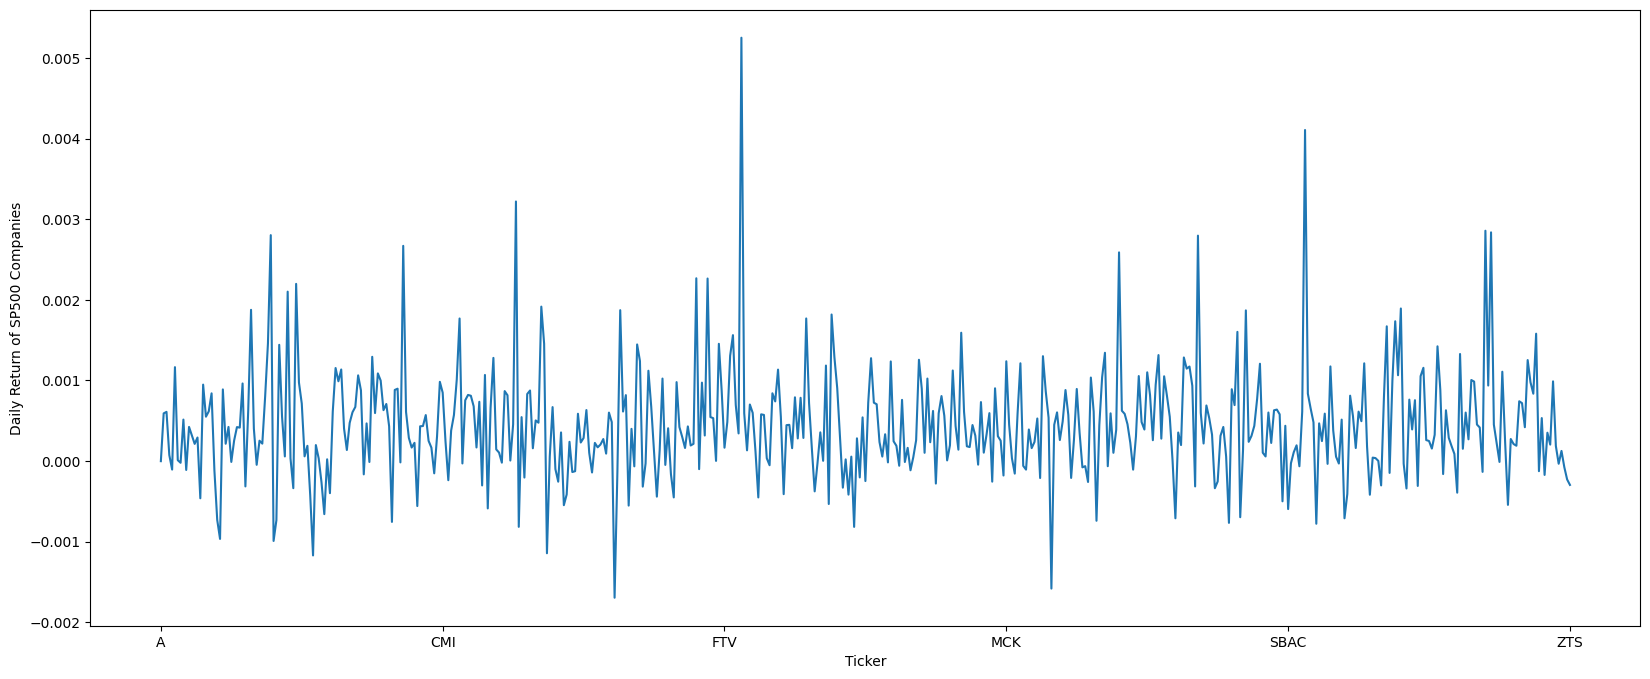

In [ ]:
from matplotlib import pyplot as plt
plt.figure(figsize=(20,8))
dr_mean.plot()
plt.ylabel("Daily Return of SP500 Companies")
plt.show()

# ***Beta Calculation:***

In [ ]:
def fetch_data(tickers, index='^GSPC', start=None, end=None, interval='1d'):
    all_tickers = tickers + [index]
    df = yf.download(all_tickers, start=start, end=end, interval=interval)['Close']
    return df

In [ ]:
def calculate_ratios(returns, benchmark_returns, risk_free_rate=0.04/252):
    excess = returns - risk_free_rate
    downside = excess[excess < 0]

    beta = np.cov(returns, benchmark_returns)[0,1] / np.var(benchmark_returns)
    return beta

In [ ]:
def build_screener(tickers, index='^GSPC', start=None, end=None, risk_free_rate=0.04/252):
    df = fetch_data(tickers, index=index, start=start, end=end)
    benchmark = df[index].pct_change().dropna()
    results = []

    for ticker in tickers:
        ret = df[ticker].pct_change().dropna()
        aligned = pd.concat([ret, benchmark], axis=1, join='inner').dropna()
        beta = calculate_ratios(aligned[ticker], aligned[index], risk_free_rate)
        results.append({'Ticker': ticker, 'Beta': beta})

    return pd.DataFrame(results).sort_values('Beta', ascending=False)

In [ ]:
import numpy as np
df = build_screener(tickers, index='^GSPC', start=start, end=end)
print(df)

/tmp/ipykernel_17626/2721606737.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(all_tickers, start=start, end=end, interval=interval)['Close']
[*********************100%***********************]  504 of 504 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')
/tmp/ipykernel_17626/3292031660.py:7: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = df[ticker].pct_change().dropna()
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/loca

    Ticker      Beta
88    CVNA  3.298454
118   COIN  2.964902
67     XYZ  2.548173
344   NVDA  2.271536
40     APP  2.264945
..     ...       ...
414    SJM  0.196851
83     CPB  0.133844
219    GIS  0.133427
386      Q       NaN
405   SNDK       NaN

[503 rows x 2 columns]


In [ ]:
df.head(20)

,Ticker,Beta
88,CVNA,3.298454
118,COIN,2.964902
67,XYZ,2.548173
344,NVDA,2.271536
40,APP,2.264945
446,TTD,2.240102
357,PLTR,2.192504
321,MPWR,2.136973
6,AMD,2.067498
472,VRT,2.063659


In [ ]:
import statistics
Annual_vol == daily_returns.std() * np.sqrt(252)
Annual_vol.name = 'Annual Volatility'
Annual_vol

,Annual Volatility
Ticker,
A,0.296259
AAPL,0.270935
ABBV,0.219958
ABNB,0.467875
ABT,0.217839
...,...
XYZ,0.653825
YUM,0.191335
ZBH,0.245157


In [ ]:

all_dim = df.merge(Annual_vol, left_on='Ticker', right_index=True)
all_dim = all_dim.merge(dr_mean, left_on='Ticker', right_index=True)
all_dim

,Ticker,Beta,Annual Volatility,Average Daily returns
88,CVNA,3.298454,1.341039,0.003219
118,COIN,2.964902,0.953848,0.001768
67,XYZ,2.548173,0.653825,-0.000034
344,NVDA,2.271536,0.552710,0.002588
40,APP,2.264945,0.788374,0.002802
...,...,...,...,...
292,LMT,0.244190,0.209530,0.000611
238,HRL,0.236923,0.232603,-0.000376
414,SJM,0.196851,0.219994,-0.000065
83,CPB,0.133844,0.223119,0.000168


In [ ]:
all_dim_100 = all_dim.iloc[:100]

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

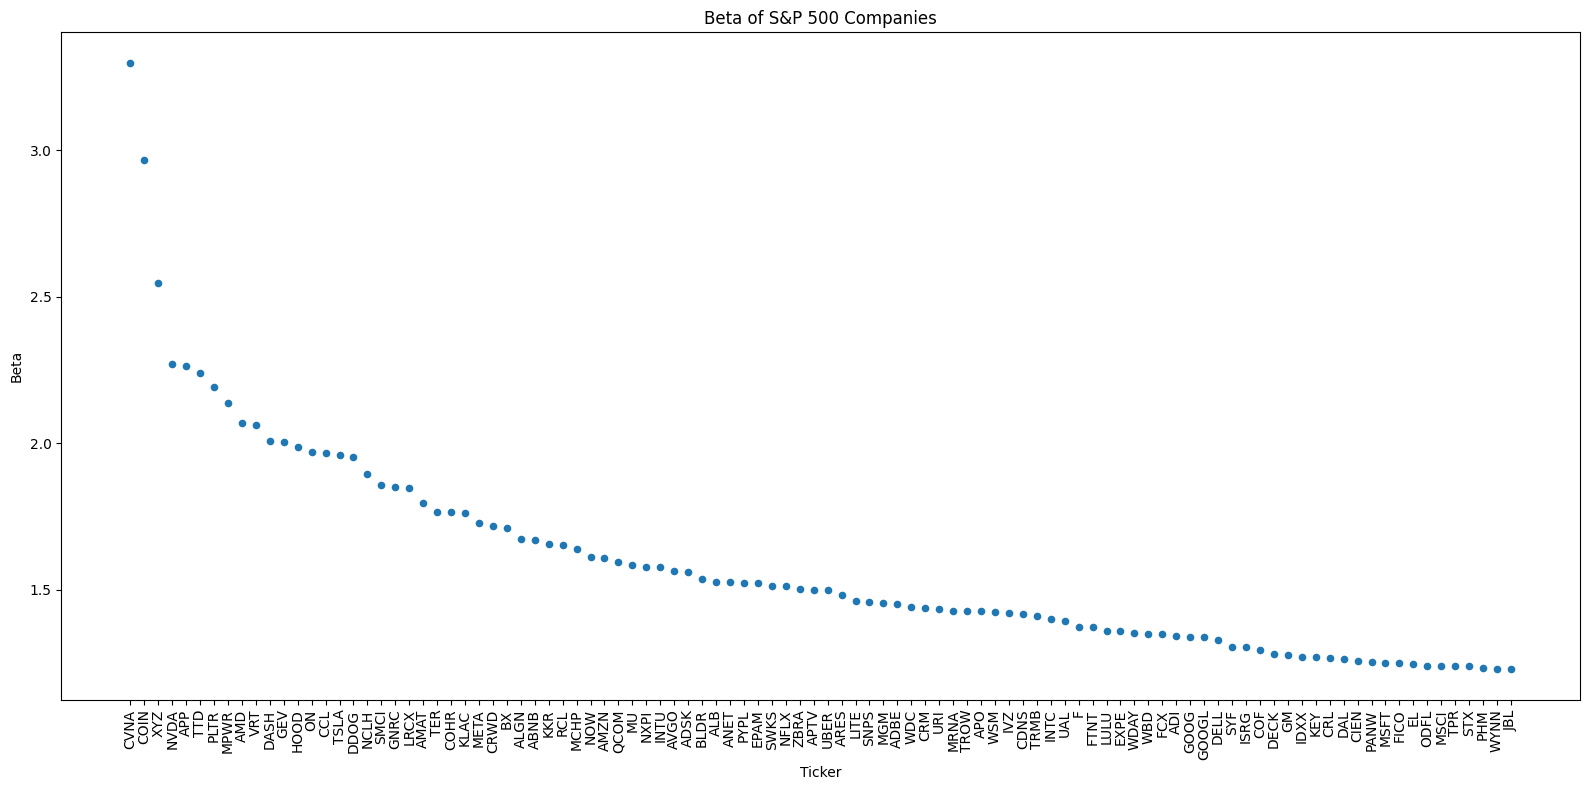

In [ ]:
all_dim_100.plot(x='Ticker', y=['Beta'], kind='scatter', figsize=(16,8))
plt.title('Beta of S&P 500 Companies')
plt.xlabel('Ticker')
plt.ylabel('Beta')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

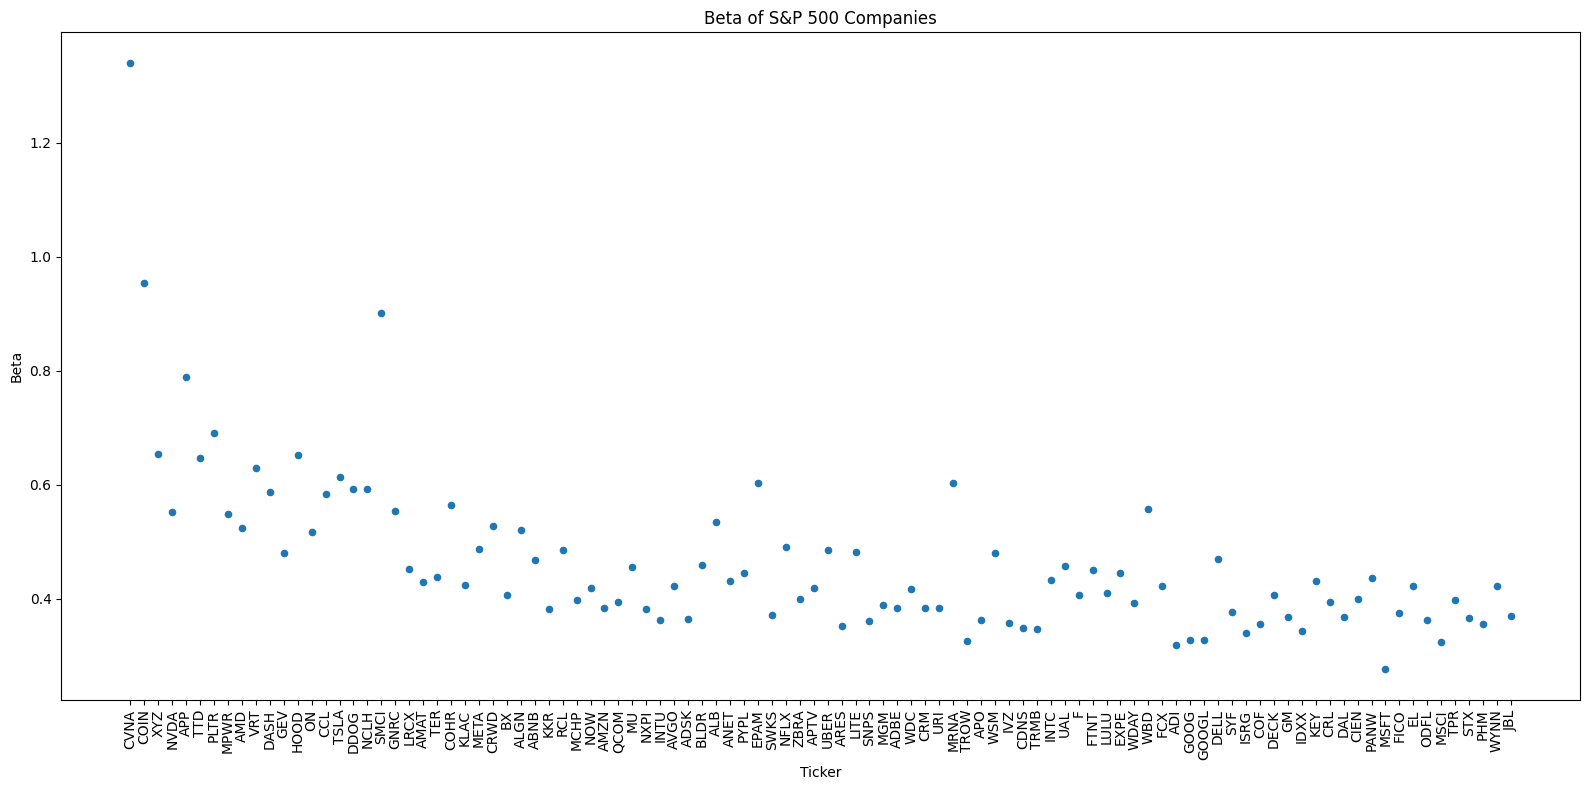

In [ ]:
all_dim_100.plot(x='Ticker', y=['Annual Volatility'], kind='scatter', figsize=(16,8))
plt.title('Beta of S&P 500 Companies')
plt.xlabel('Ticker')
plt.ylabel('Beta')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
all_dim_100.plot(x='Ticker', y=['Beta'], kind='scatter', figsize=(16,8))
plt.title('Beta of S&P 500 Companies')
plt.xlabel('Ticker')
plt.ylabel('Beta')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

In [ ]:
px.scatter(all_dim_100, x='Ticker', y='Beta')

## **Part B: Customer Segmentation:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage


In [ ]:
# Select the three dimensions required for clustering
features = all_dim[['Average Daily returns', 'Beta', 'Annual Volatility']].copy()
features = features.dropna()
features

,Average Daily returns,Beta,Annual Volatility
88,0.003219,3.298454,1.341039
118,0.001768,2.964902,0.953848
67,-0.000034,2.548173,0.653825
344,0.002588,2.271536,0.552710
40,0.002802,2.264945,0.788374
...,...,...,...
292,0.000611,0.244190,0.209530
238,-0.000376,0.236923,0.232603
414,-0.000065,0.196851,0.219994
83,0.000168,0.133843,0.223119


In [ ]:
# Apply Box-Cox transformation to reduce skewness (same approach as class)
features_fix = pd.DataFrame()
features_fix['Daily Return']      = stats.boxcox(features['Average Daily returns']      + abs(features['Average Daily returns'].min()) + 0.0001)[0]
features_fix['Beta']              = stats.boxcox(features['Beta']              + abs(features['Beta'].min())         + 0.0001)[0]
features_fix['Annual Volatility'] = stats.boxcox(features['Annual Volatility'] + abs(features['Annual Volatility'].min()) + 0.0001)[0]
features_fix.tail()

,Daily Return,Beta,Annual Volatility
496,-1.806248,-0.874500,-2.890763
497,-1.824969,-0.890076,-2.527158
498,-1.818547,-0.980501,-2.718041
499,-1.814085,-1.141636,-2.669062
500,-1.814748,-1.142798,-3.089859


In [ ]:
# Standardise the data (mean=0, std=1)
scaler = StandardScaler()
scaler.fit(features_fix)
features_normalized = scaler.transform(features_fix)

# Confirm normalisation
print(features_normalized.mean(axis=0).round(2))  # [0. 0. 0.]
print(features_normalized.std(axis=0).round(2))   # [1. 1. 1.]

[ 0. -0. -0.]
[1. 1. 1.]


Dendogram to identify number of clusters


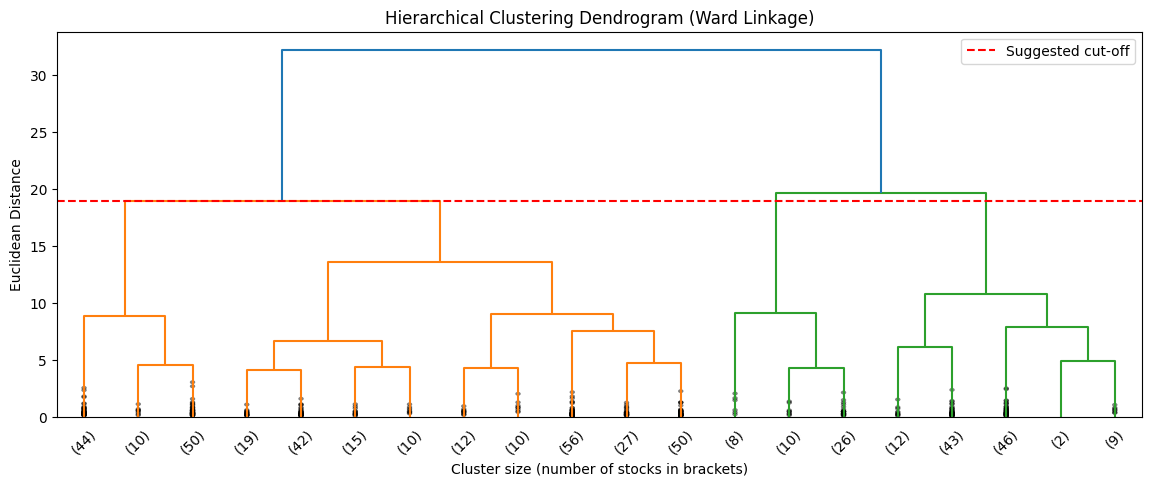

In [ ]:
# Dendrogram to visually identify the best number of clusters (N)
# Ward linkage minimises within-cluster variance - appropriate for compact clusters
linked = linkage(features_normalized, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(linked, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster size (number of stocks in brackets)')
plt.ylabel('Euclidean Distance')
plt.axhline(y=linked[-3, 2], color='red', linestyle='--', label='Suggested cut-off')
plt.legend()
plt.show()

Average silhouette score: 0.2698


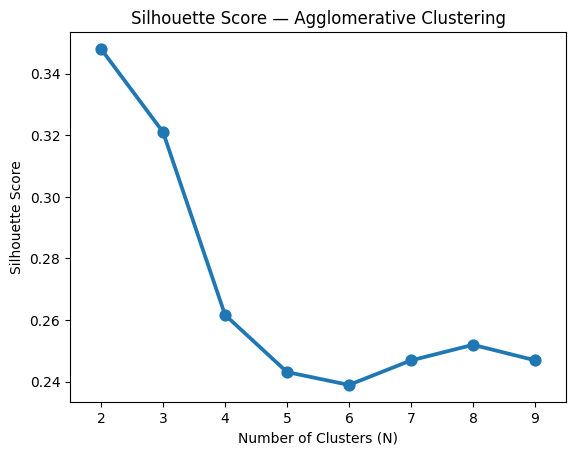

In [ ]:
# Silhouette Score to confirm the best value of N
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

X = features_normalized
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9]
scores = []

for n_clusters in range_n_clusters:
    agglom = AgglomerativeClustering(n_clusters=n_clusters)
    agglom.fit(X)
    labels = agglom.labels_
    scores.append(silhouette_score(X, labels))

# Show average silhouette score
average = sum(scores) / len(scores)
print('Average silhouette score:', round(average, 4))

# Plot silhouette scores
plt.title('Silhouette Score — Agglomerative Clustering')
plt.xlabel('Number of Clusters (N)')
plt.ylabel('Silhouette Score')
sns.pointplot(x=range_n_clusters, y=scores)
plt.show()

In [ ]:
# Review individual scores and pick the best N
for n, s in zip(range_n_clusters, scores):
    print(f'N={n}  Silhouette Score={round(s, 4)}')

N=2  Silhouette Score=0.348
N=3  Silhouette Score=0.321
N=4  Silhouette Score=0.2617
N=5  Silhouette Score=0.2431
N=6  Silhouette Score=0.2389
N=7  Silhouette Score=0.2469
N=8  Silhouette Score=0.252
N=9  Silhouette Score=0.2469


Cluster 1 has 156 observations
Cluster 2 has 345 observations


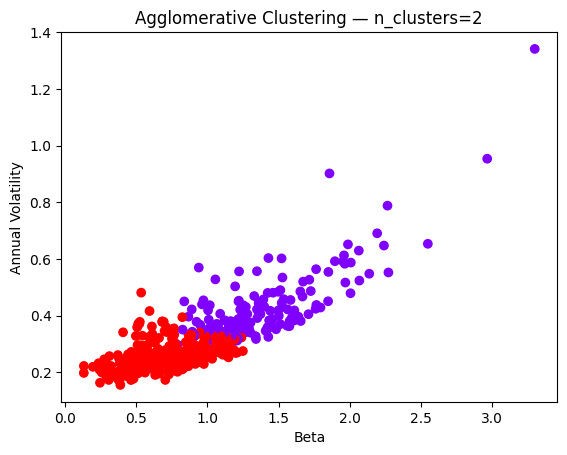

Cluster 1 has 345 observations
Cluster 2 has 112 observations
Cluster 3 has 44 observations


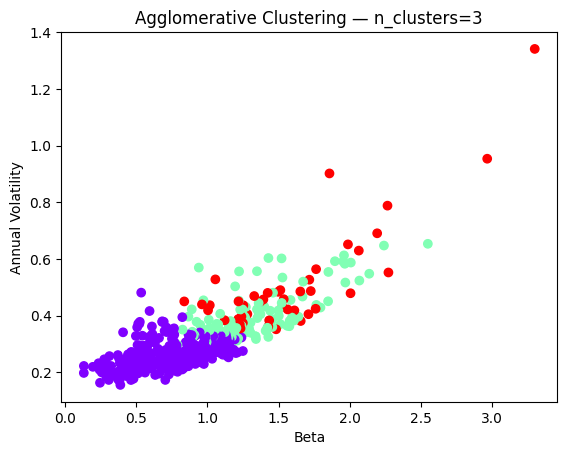

Cluster 1 has 241 observations
Cluster 2 has 112 observations
Cluster 3 has 44 observations
Cluster 4 has 104 observations


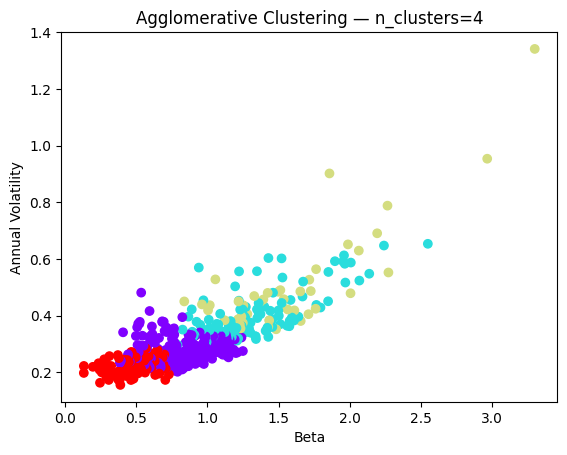

Cluster 1 has 112 observations
Cluster 2 has 155 observations
Cluster 3 has 44 observations
Cluster 4 has 104 observations
Cluster 5 has 86 observations


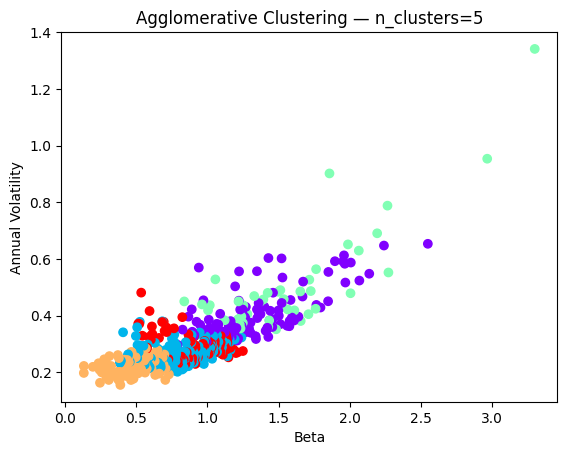

Cluster 1 has 44 observations
Cluster 2 has 155 observations
Cluster 3 has 57 observations
Cluster 4 has 104 observations
Cluster 5 has 86 observations
Cluster 6 has 55 observations


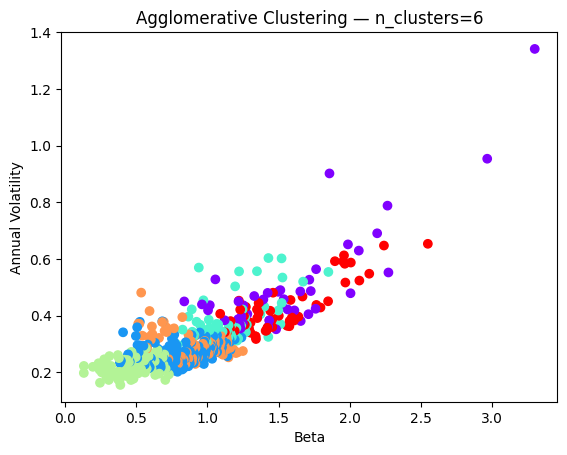

Cluster 1 has 155 observations
Cluster 2 has 104 observations
Cluster 3 has 57 observations
Cluster 4 has 36 observations
Cluster 5 has 86 observations
Cluster 6 has 55 observations
Cluster 7 has 8 observations


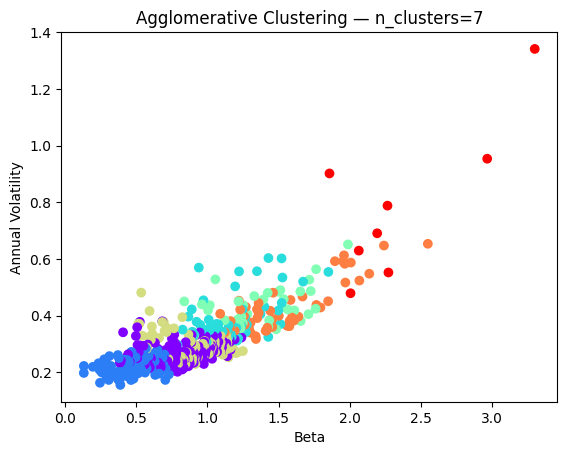

Cluster 1 has 104 observations
Cluster 2 has 133 observations
Cluster 3 has 57 observations
Cluster 4 has 22 observations
Cluster 5 has 86 observations
Cluster 6 has 55 observations
Cluster 7 has 8 observations
Cluster 8 has 36 observations


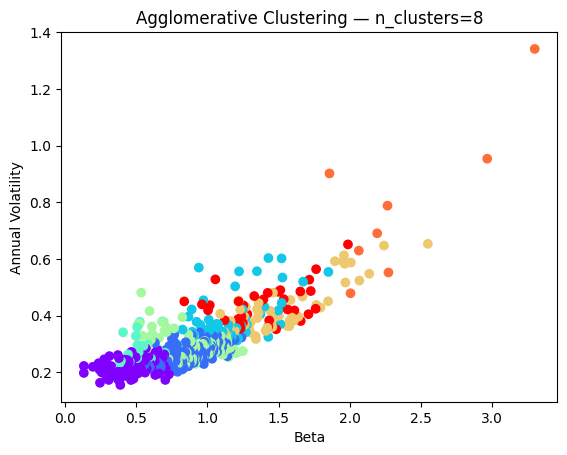

Cluster 1 has 57 observations
Cluster 2 has 133 observations
Cluster 3 has 55 observations
Cluster 4 has 22 observations
Cluster 5 has 86 observations
Cluster 6 has 60 observations
Cluster 7 has 8 observations
Cluster 8 has 36 observations
Cluster 9 has 44 observations


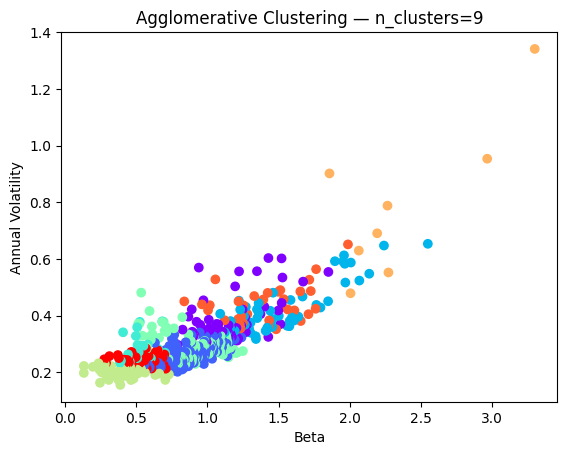

In [ ]:
# Visualise scatter plots for each N to inspect cluster separation
import numpy as np
for n_clusters in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X)
    plt.scatter(features['Beta'], features['Annual Volatility'], c=labels, cmap='rainbow')
    plt.xlabel('Beta')
    plt.ylabel('Annual Volatility')
    plt.title(f'Agglomerative Clustering — n_clusters={n_clusters}')
    cluster_counts = np.bincount(labels)
    for i in range(n_clusters):
        print(f'Cluster {i+1} has {cluster_counts[i]} observations')
    plt.show()

In [ ]:
# Apply final agglomerative model with optimal N
# (set optimal_n to whichever N had the highest silhouette score above)
optimal_n = 3

agglom_final = AgglomerativeClustering(n_clusters=optimal_n)
features['Agg_Cluster'] = agglom_final.fit_predict(X)
features

,Average Daily returns,Beta,Annual Volatility,Agg_Cluster
88,0.003219,3.298454,1.341039,2
118,0.001768,2.964902,0.953848,2
67,-0.000034,2.548173,0.653825,1
344,0.002588,2.271536,0.552710,2
40,0.002802,2.264945,0.788374,2
...,...,...,...,...
292,0.000611,0.244190,0.209530,0
238,-0.000376,0.236923,0.232603,0
414,-0.000065,0.196851,0.219994,0
83,0.000168,0.133843,0.223119,0


In [ ]:
# Profile each agglomerative cluster
features.groupby('Agg_Cluster').agg({
    'Average Daily returns': 'mean',
    'Beta': 'mean',
    'Annual Volatility': ['mean', 'count']}).round(4)

Average Daily returns    Beta Annual Volatility      
                             mean    mean              mean count
Agg_Cluster                                                      
0                          0.0004  0.7380            0.2605   345
1                          0.0000  1.3362            0.4063   112
2                          0.0018  1.5717            0.5029    44

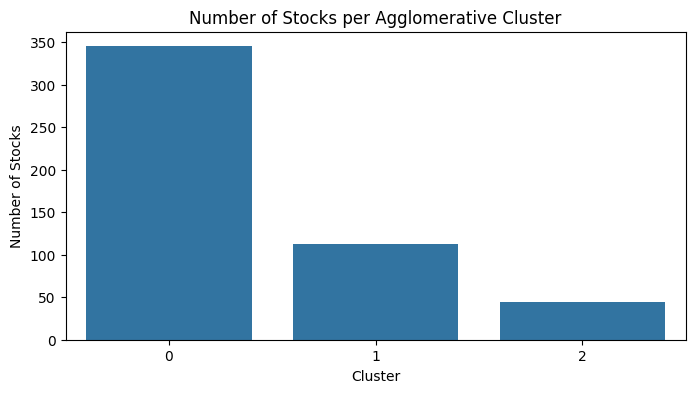

In [ ]:
# Cluster size bar chart
f, ax = plt.subplots(figsize=(8, 4))
sns.countplot(x='Agg_Cluster', data=features)
plt.title('Number of Stocks per Agglomerative Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Stocks')
plt.show()

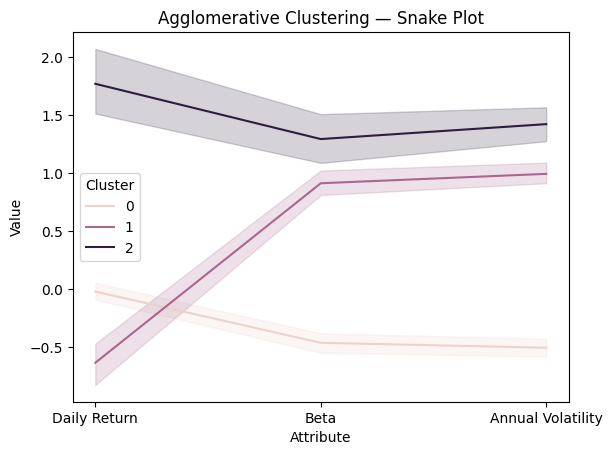

In [ ]:
# Snake plot — normalised view across all three dimensions per cluster
df_normalized_agg = pd.DataFrame(features_normalized, columns=['Daily Return', 'Beta', 'Annual Volatility'])
df_normalized_agg['Cluster'] = features['Agg_Cluster'].values

df_melt_agg = pd.melt(df_normalized_agg.reset_index(),
                      id_vars=['index', 'Cluster'],
                      value_vars=['Daily Return', 'Beta', 'Annual Volatility'],
                      var_name='Attribute',
                      value_name='Value')

sns.lineplot(x='Attribute', y='Value', hue='Cluster', data=df_melt_agg)
plt.title('Agglomerative Clustering — Snake Plot')
plt.show()

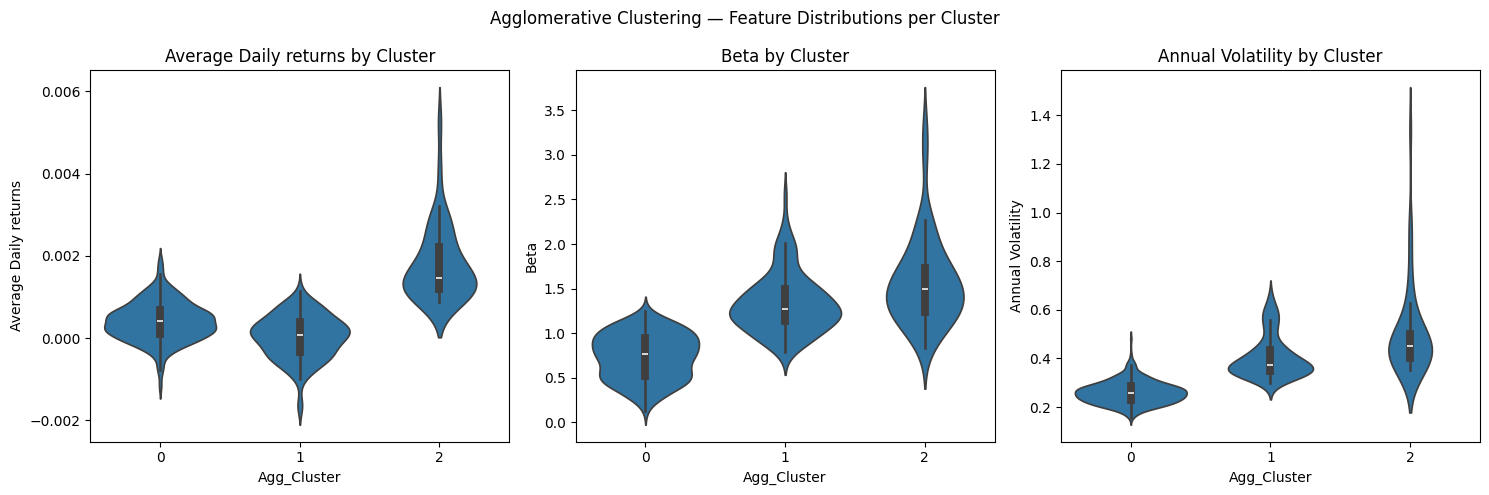

In [ ]:
# Violin plots for each feature by agglomerative cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Average Daily returns', 'Beta', 'Annual Volatility']):
    sns.violinplot(x='Agg_Cluster', y=col, data=features, ax=ax)
    ax.set_title(f'{col} by Cluster')
plt.suptitle('Agglomerative Clustering — Feature Distributions per Cluster')
plt.tight_layout()
plt.show()

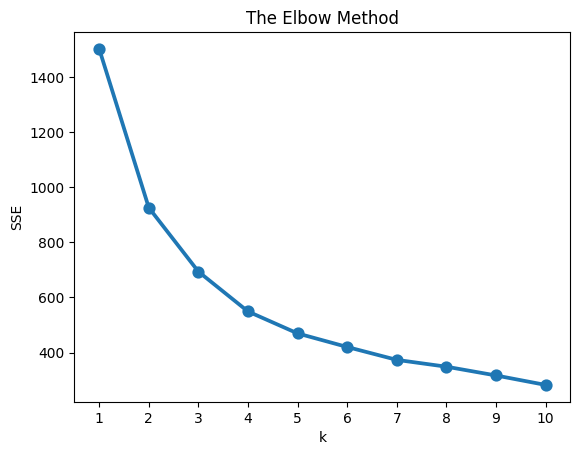

In [ ]:
# Elbow Method to find best K
from sklearn.cluster import KMeans
sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_normalized)
    sse[k] = kmeans.inertia_  # SSE to closest cluster centroid

plt.title('The Elbow Method')
plt.xlabel('k')
plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

Average silhouette score: 0.2917


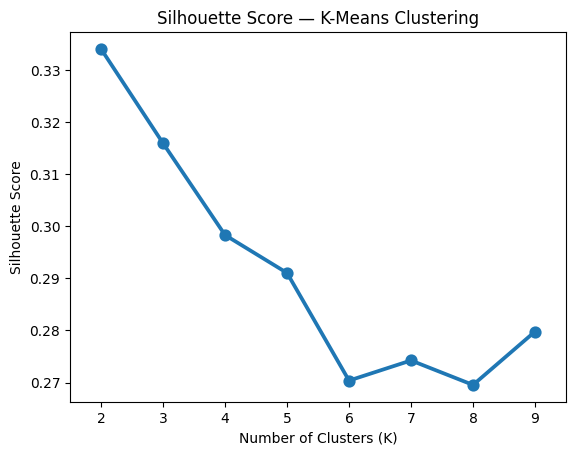

In [ ]:
# Silhouette Score to confirm the best K
range_k = [2, 3, 4, 5, 6, 7, 8, 9]
k_scores = []

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_normalized)
    k_scores.append(silhouette_score(features_normalized, kmeans.labels_))

average_k = sum(k_scores) / len(k_scores)
print('Average silhouette score:', round(average_k, 4))

plt.title('Silhouette Score — K-Means Clustering')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
sns.pointplot(x=range_k, y=k_scores)
plt.show()

In [ ]:
# Review individual scores and pick the best K
for k, s in zip(range_k, k_scores):
    print(f'K={k}  Silhouette Score={round(s, 4)}')

K=2  Silhouette Score=0.334
K=3  Silhouette Score=0.3159
K=4  Silhouette Score=0.2983
K=5  Silhouette Score=0.291
K=6  Silhouette Score=0.2704
K=7  Silhouette Score=0.2742
K=8  Silhouette Score=0.2696
K=9  Silhouette Score=0.2798


In [ ]:
# Apply final K-Means model with optimal K
# (set optimal_k to whichever K had the elbow + highest silhouette above)
optimal_k = 4

model = KMeans(n_clusters=optimal_k, random_state=42)
model.fit(features_normalized)
model.labels_.shape

features['Cluster'] = model.labels_
features.groupby('Cluster').agg({
    'Average Daily returns': 'mean',
    'Beta': 'mean',
    'Annual Volatility': ['mean', 'count']}).round(4)

Average Daily returns    Beta Annual Volatility      
                         mean    mean              mean count
Cluster                                                      
0                      0.0006  0.9235            0.2883   190
1                      0.0003  0.5175            0.2226   144
2                      0.0015  1.6289            0.4957    64
3                     -0.0002  1.1572            0.3779   103

,Average Daily returns,Beta,Annual Volatility,Agg_Cluster
Cluster,,,,
0,190,190,190,190
1,144,144,144,144
2,64,64,64,64
3,103,103,103,103


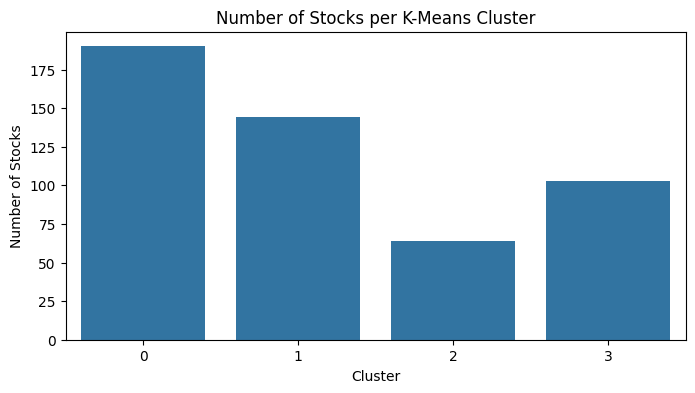

In [ ]:
# Cluster size bar chart
f, ax = plt.subplots(figsize=(8, 4))
ax = sns.countplot(x='Cluster', data=features)
plt.title('Number of Stocks per K-Means Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Stocks')
features.groupby(['Cluster']).count()

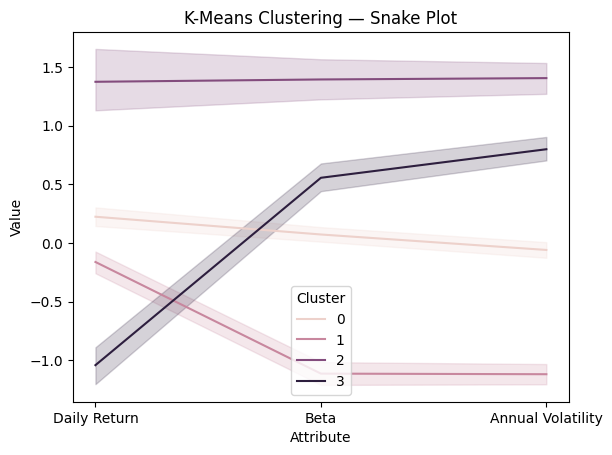

In [ ]:
# Snake plot — normalised view across all three dimensions per cluster
df_normalized_km = pd.DataFrame(features_normalized, columns=['Daily Return', 'Beta', 'Annual Volatility'])
df_normalized_km['ID'] = features.index
df_normalized_km['Cluster'] = model.labels_

df_nor_melt = pd.melt(df_normalized_km.reset_index(),
                      id_vars=['ID', 'Cluster'],
                      value_vars=['Daily Return', 'Beta', 'Annual Volatility'],
                      var_name='Attribute',
                      value_name='Value')
df_nor_melt.head()

# Visualise it
sns.lineplot(x='Attribute', y='Value', hue='Cluster', data=df_nor_melt)
plt.title('K-Means Clustering — Snake Plot')
plt.show()

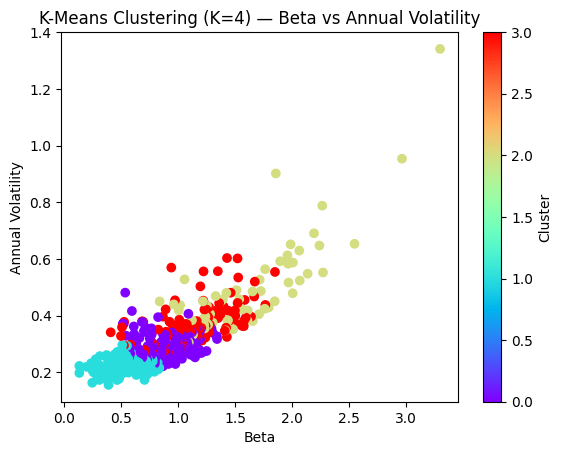

In [ ]:
# Scatter plot: Beta vs Annual Volatility coloured by K-Means cluster
plt.scatter(features['Beta'], features['Annual Volatility'],
            c=features['Cluster'], cmap='rainbow')
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.title(f'K-Means Clustering (K={optimal_k}) — Beta vs Annual Volatility')
plt.colorbar(label='Cluster')
plt.show()

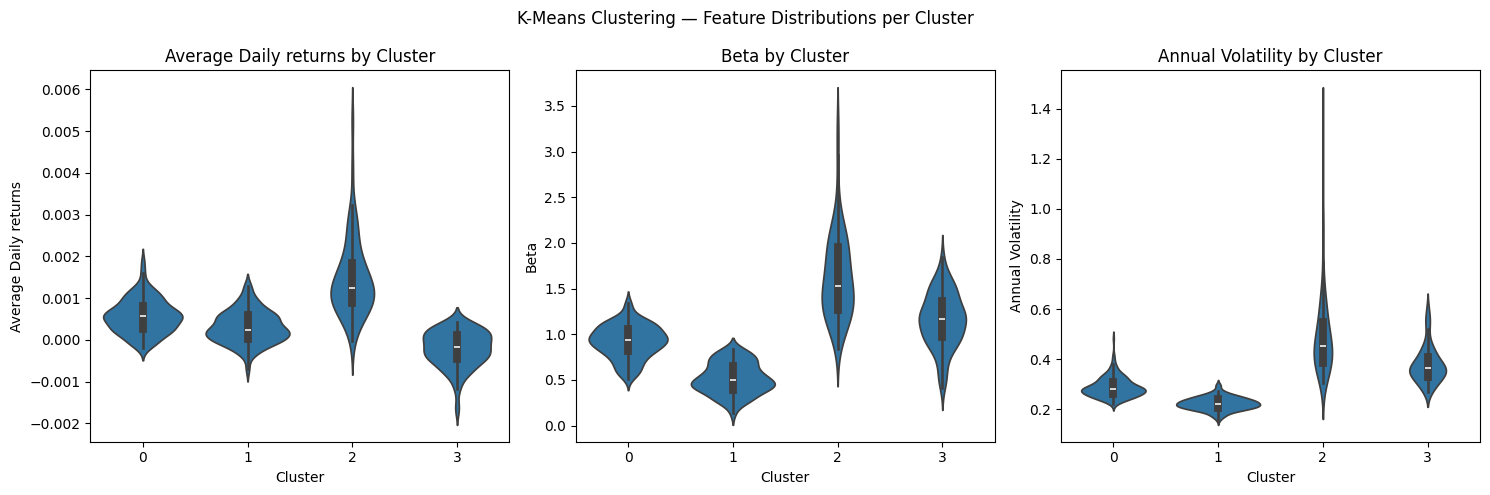

In [ ]:
# Violin plots for each feature by K-Means cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Average Daily returns', 'Beta', 'Annual Volatility']):
    sns.violinplot(x='Cluster', y=col, data=features, ax=ax)
    ax.set_title(f'{col} by Cluster')
plt.suptitle('K-Means Clustering — Feature Distributions per Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# Final cluster profile summary
features['Cluster'] = model.labels_
features.groupby('Cluster').agg({
    'Average Daily returns': 'mean',
    'Beta': 'mean',
    'Annual Volatility': ['mean', 'count']}).round(4)

Average Daily returns    Beta Annual Volatility      
                         mean    mean              mean count
Cluster                                                      
0                      0.0006  0.9235            0.2883   190
1                      0.0003  0.5175            0.2226   144
2                      0.0015  1.6289            0.4957    64
3                     -0.0002  1.1572            0.3779   103